In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
final_dataset_df = pd.read_csv('final_dataset.csv')

## Data Cleaning

In [5]:
final_dataset_df.head()

,appointment_id,appointment_patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,treatment_id,treatment_type,description,...,first_name_y,last_name_y,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email_y
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,T001,Chemotherapy,Basic screening,...,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,T002,MRI,Advanced protocol,...,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,T003,MRI,Standard procedure,...,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,T004,MRI,Basic screening,...,Robert,Wilson,M,1966-08-14,7482069727,123 Elm St,2021-09-09,HealthIndia,INS833429,robert.wilson@mail.com
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show,T005,ECG,Standard procedure,...,Emily,Williams,M,1972-05-30,7587653815,456 Oak Ave,2021-10-16,PulseSecure,INS320984,emily.williams@mail.com


In [6]:
final_dataset_df.isnull().sum()

appointment_id            0
appointment_patient_id    0
doctor_id                 0
appointment_date          0
appointment_time          0
reason_for_visit          0
status                    0
treatment_id              0
treatment_type            0
description               0
cost                      0
treatment_date            0
bill_id                   0
billing_patient_id        0
bill_date                 0
amount                    0
payment_method            0
payment_status            0
first_name_x              0
last_name_x               0
specialization            0
phone_number              0
years_experience          0
hospital_branch           0
email_x                   0
patient_id                0
first_name_y              0
last_name_y               0
gender                    0
date_of_birth             0
contact_number            0
address                   0
registration_date         0
insurance_provider        0
insurance_number          0
email_y             

In [7]:
final_dataset_df.dtypes

appointment_id             object
appointment_patient_id     object
doctor_id                  object
appointment_date           object
appointment_time           object
reason_for_visit           object
status                     object
treatment_id               object
treatment_type             object
description                object
cost                      float64
treatment_date             object
bill_id                    object
billing_patient_id         object
bill_date                  object
amount                    float64
payment_method             object
payment_status             object
first_name_x               object
last_name_x                object
specialization             object
phone_number                int64
years_experience            int64
hospital_branch            object
email_x                    object
patient_id                 object
first_name_y               object
last_name_y                object
gender                     object
date_of_birth 

In [8]:
final_dataset_df.columns

Index(['appointment_id', 'appointment_patient_id', 'doctor_id',
       'appointment_date', 'appointment_time', 'reason_for_visit', 'status',
       'treatment_id', 'treatment_type', 'description', 'cost',
       'treatment_date', 'bill_id', 'billing_patient_id', 'bill_date',
       'amount', 'payment_method', 'payment_status', 'first_name_x',
       'last_name_x', 'specialization', 'phone_number', 'years_experience',
       'hospital_branch', 'email_x', 'patient_id', 'first_name_y',
       'last_name_y', 'gender', 'date_of_birth', 'contact_number', 'address',
       'registration_date', 'insurance_provider', 'insurance_number',
       'email_y'],
      dtype='object')

## Data Analysis

In [9]:
# Set style for all plots
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)

In [10]:
analysis_df =final_dataset_df[['treatment_type', 'specialization', 'cost']].copy()

In [11]:
print("Unique Treatment Types:", analysis_df['treatment_type'].nunique())

Unique Treatment Types: 5


In [12]:
print("Unique Specializations:", analysis_df['specialization'].nunique())

Unique Specializations: 3


In [13]:
print("\nTop 5 Treatment Types by Frequency:")
print(analysis_df['treatment_type'].value_counts().head())


Top 5 Treatment Types by Frequency:
treatment_type
Chemotherapy     49
X-Ray            41
ECG              38
MRI              36
Physiotherapy    36
Name: count, dtype: int64


In [14]:
print("\nTop 5 Specializations by Frequency:")
print(analysis_df['specialization'].value_counts().head())


Top 5 Specializations by Frequency:
specialization
Pediatrics     98
Dermatology    70
Oncology       32
Name: count, dtype: int64


### Average Cost by Treatment Type

C:\Users\ankit\AppData\Local\Temp\ipykernel_25368\1055440561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cost_by_treatment.values, y=avg_cost_by_treatment.index, palette='viridis')


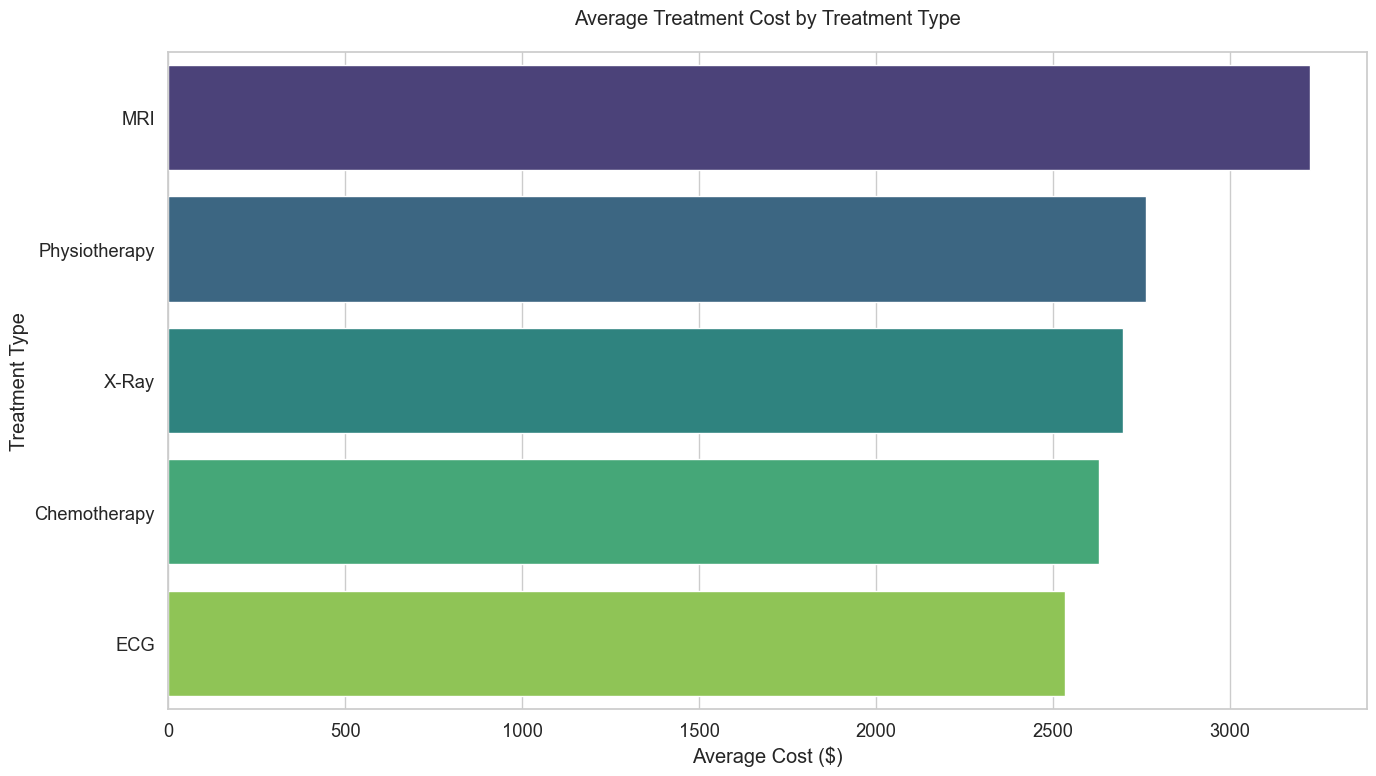

In [15]:
plt.figure(figsize=(14, 8))
avg_cost_by_treatment = analysis_df.groupby('treatment_type')['cost'].mean().sort_values(ascending=False)
sns.barplot(x=avg_cost_by_treatment.values, y=avg_cost_by_treatment.index, palette='viridis')
plt.title('Average Treatment Cost by Treatment Type', pad=20)
plt.xlabel('Average Cost ($)')
plt.ylabel('Treatment Type')
plt.tight_layout()
plt.show()

### Cost Distribution by Treatment Type

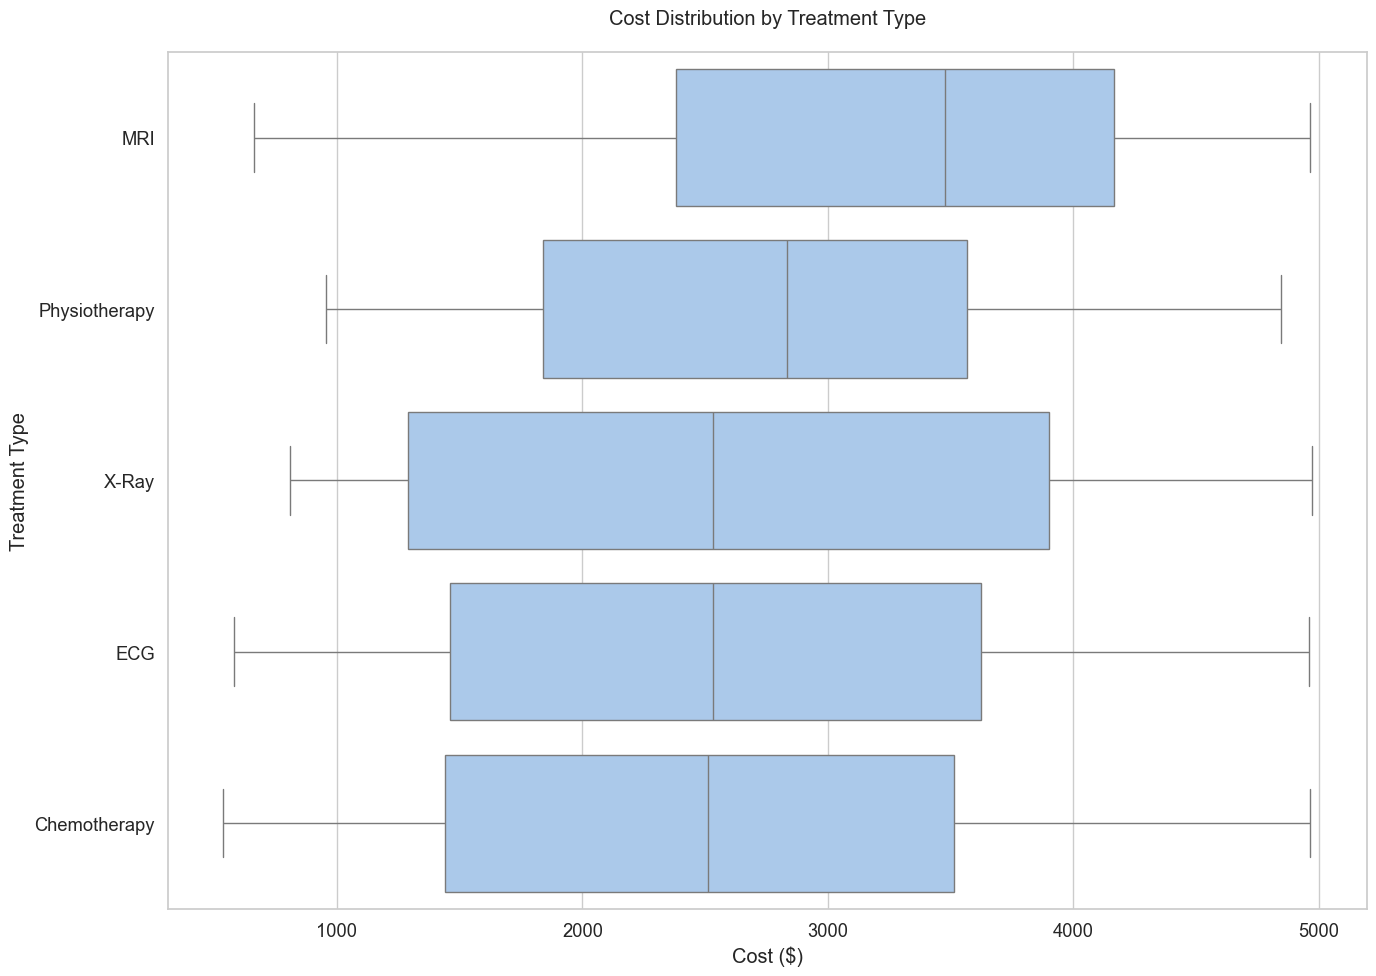

In [16]:
plt.figure(figsize=(14, 10))
sns.boxplot(data=analysis_df, x='cost', y='treatment_type', 
           order=analysis_df.groupby('treatment_type')['cost'].median().sort_values(ascending=False).index)
plt.title('Cost Distribution by Treatment Type', pad=20)
plt.xlabel('Cost ($)')
plt.ylabel('Treatment Type')
plt.tight_layout()
plt.show()

### Heatmap of Specialization vs Treatment Type

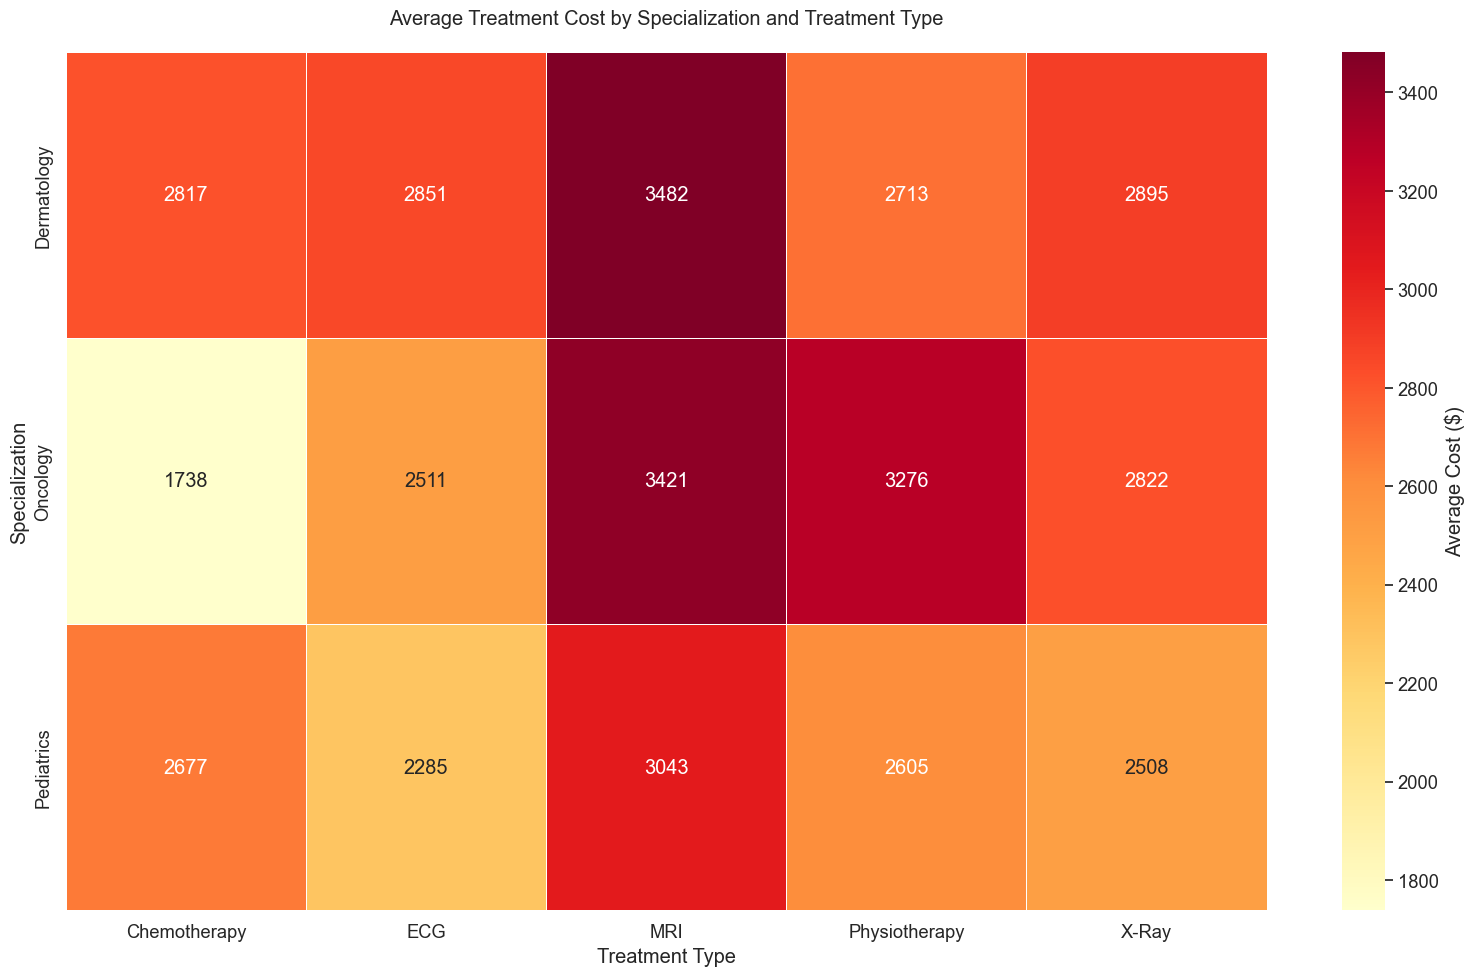

In [17]:
plt.figure(figsize=(16, 10))
heatmap_data = analysis_df.pivot_table(index='specialization', columns='treatment_type', 
                                      values='cost', aggfunc='mean')
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', 
           linewidths=.5, cbar_kws={'label': 'Average Cost ($)'})
plt.title('Average Treatment Cost by Specialization and Treatment Type', pad=20)
plt.xlabel('Treatment Type')
plt.ylabel('Specialization')
plt.tight_layout()
plt.show()

### Violin Plot of Cost Distribution

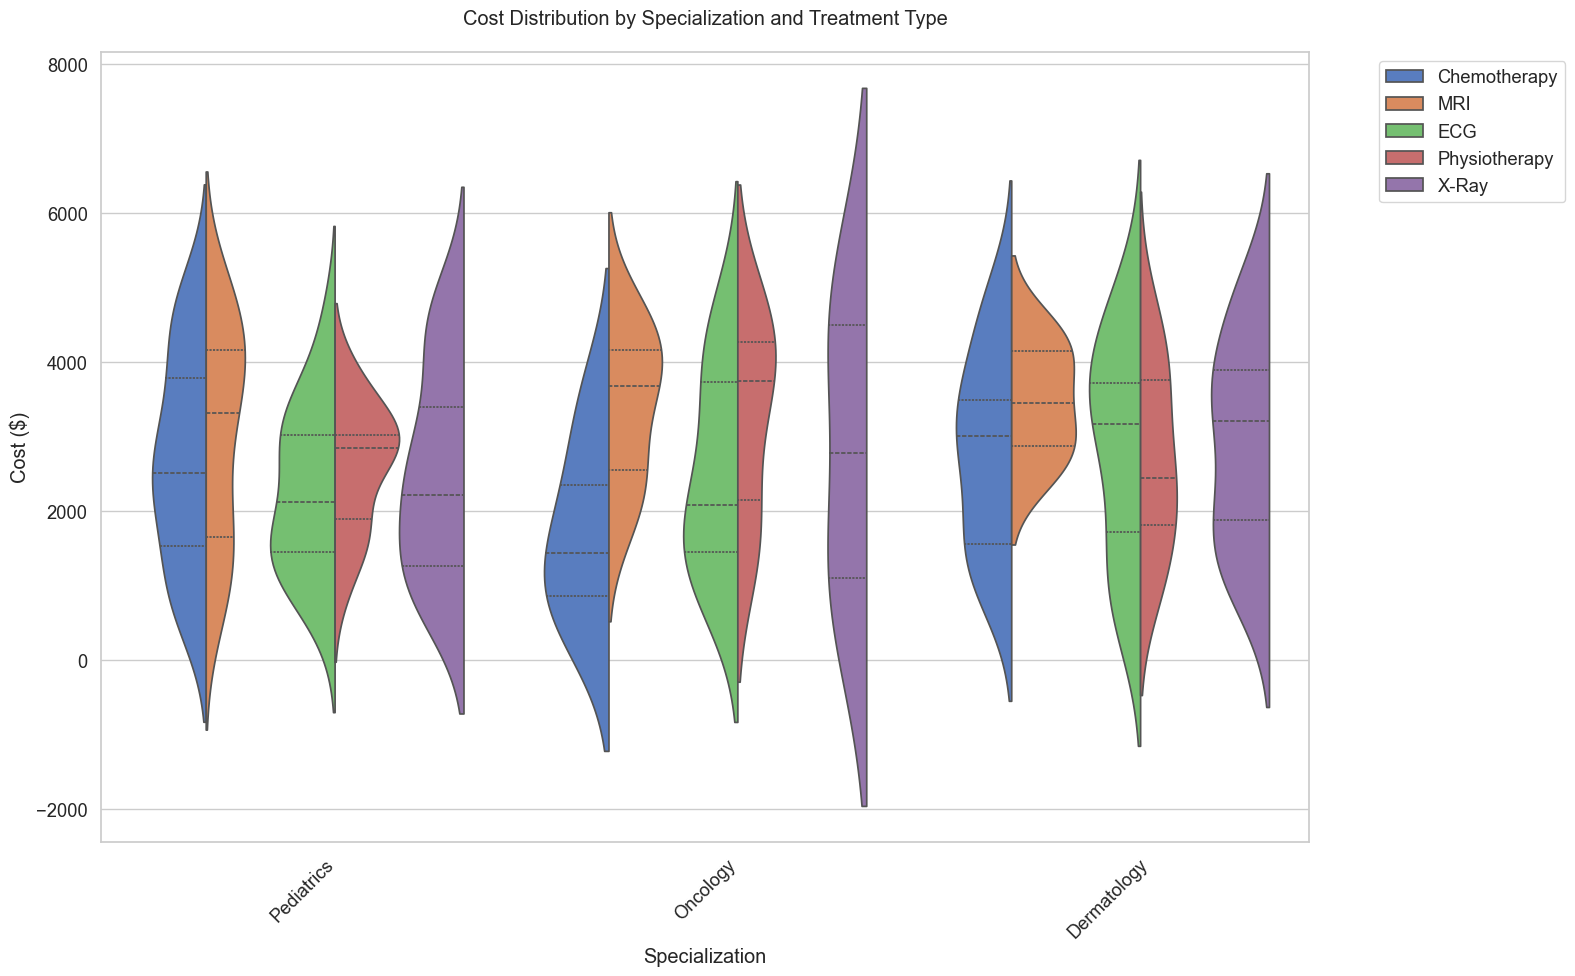

In [18]:
plt.figure(figsize=(16, 10))
top_specializations = analysis_df['specialization'].value_counts().head(8).index
filtered_df = analysis_df[analysis_df['specialization'].isin(top_specializations)]
sns.violinplot(data=filtered_df, x='specialization', y='cost', hue='treatment_type',
              split=True, inner="quart", palette="muted")
plt.title('Cost Distribution by Specialization and Treatment Type', pad=20)
plt.xlabel('Specialization')
plt.ylabel('Cost ($)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Facet Grid by Treatment Type

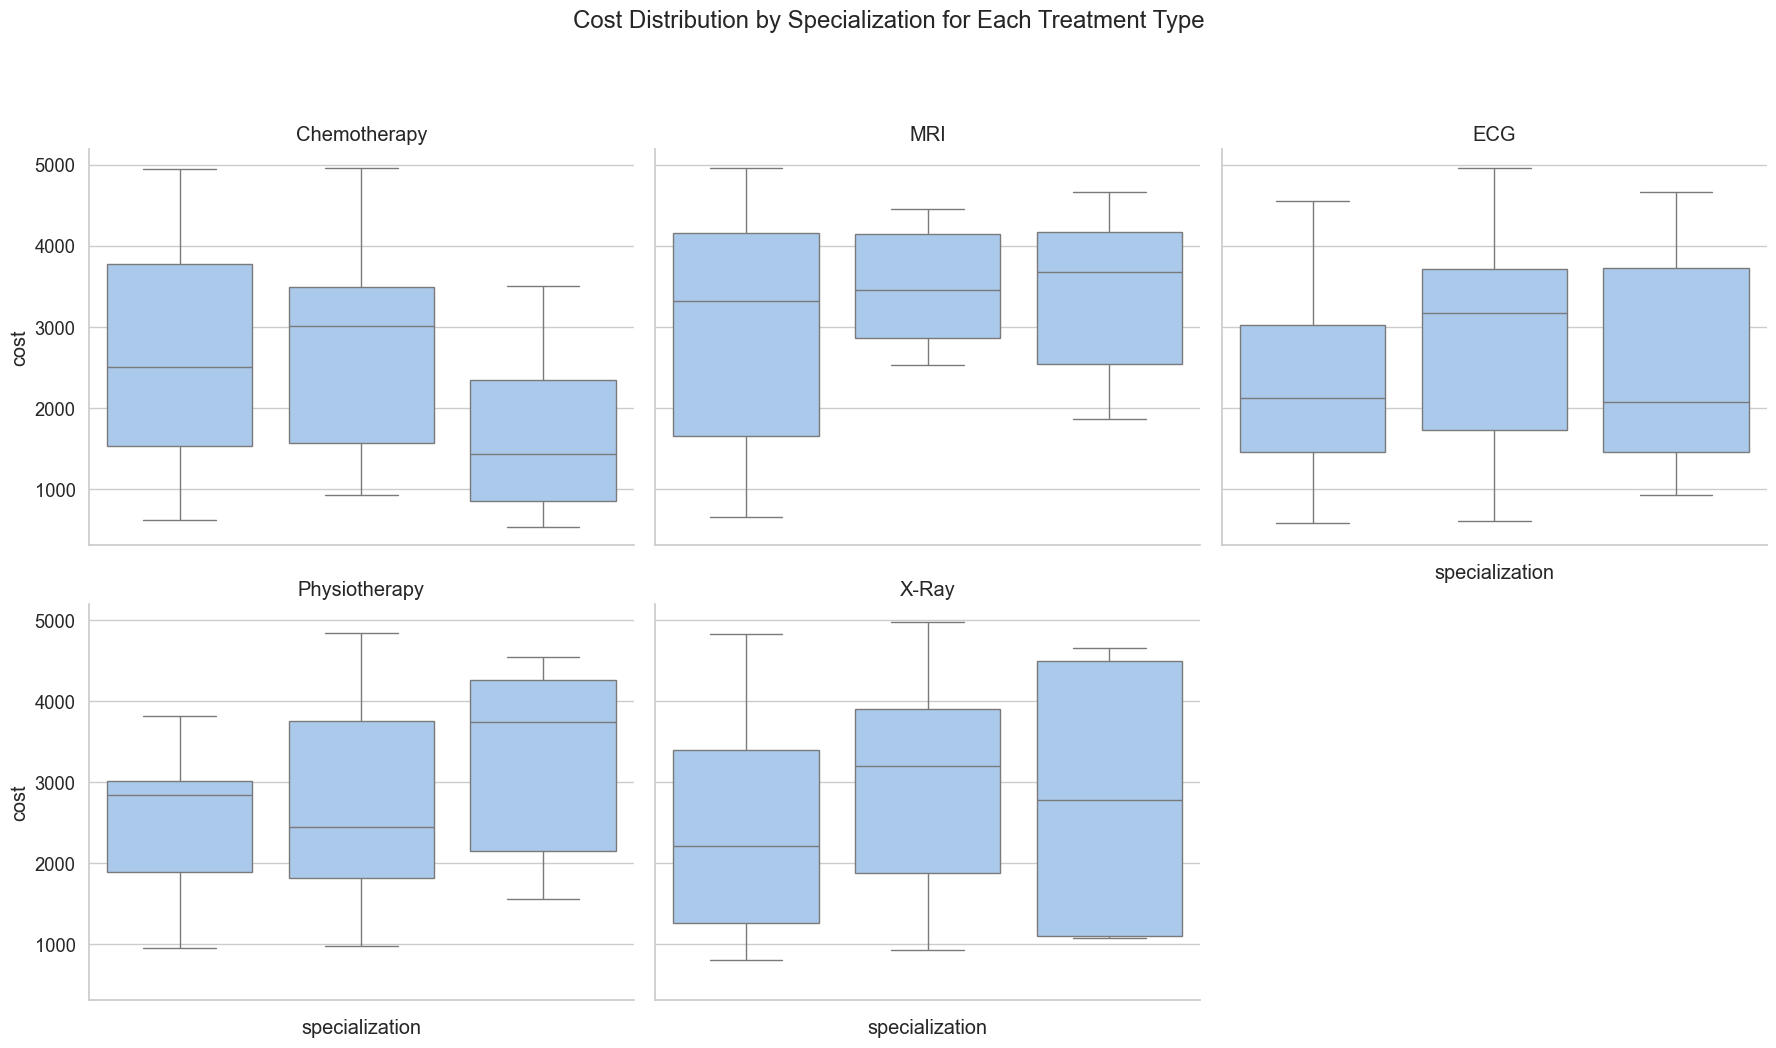

In [19]:
g = sns.FacetGrid(data=analysis_df, col='treatment_type', col_wrap=3, height=5, aspect=1.2)
g.map(sns.boxplot, 'specialization', 'cost', order=analysis_df['specialization'].value_counts().index[:5])
g.set_xticklabels(rotation=45)
g.set_titles("{col_name}")
g.fig.suptitle('Cost Distribution by Specialization for Each Treatment Type', y=1.05)
plt.tight_layout()
plt.show()

## Feature Engineering

In [20]:
final_dataset_df['date_of_birth'] = pd.to_datetime(final_dataset_df['date_of_birth'])
final_dataset_df['date_of_birth'] = (pd.to_datetime('today') - final_dataset_df['date_of_birth']).dt.days // 365

In [21]:
final_dataset_df['registration_date'] = pd.to_datetime(final_dataset_df['registration_date'])
final_dataset_df['registration_date'] = (pd.to_datetime('today') - final_dataset_df['registration_date']).dt.days

In [22]:
final_dataset_df['treatment_date'] = pd.to_datetime(final_dataset_df['treatment_date'])
final_dataset_df['treatment_date'] = (pd.to_datetime('today') - final_dataset_df['treatment_date']).dt.days

In [23]:
final_dataset_df['bill_date'] = pd.to_datetime(final_dataset_df['bill_date'])
final_dataset_df['bill_date'] = (pd.to_datetime('today') - final_dataset_df['bill_date']).dt.days

In [24]:
final_dataset_df['appointment_date'] = pd.to_datetime(final_dataset_df['appointment_date'])
final_dataset_df['appointment_date'] = (pd.to_datetime('today') - final_dataset_df['appointment_date']).dt.days

In [25]:
final_dataset_df['appointment_time']=pd.to_datetime(final_dataset_df['appointment_time'],format='%H:%M:%S')
final_dataset_df['appointment_time']=final_dataset_df['appointment_time'].dt.hour*60 + final_dataset_df['appointment_time'].dt.minute

In [26]:
# Dropping the columns that won't be used in the model
final_dataset_df.drop(columns=['appointment_id','insurance_provider' ,'appointment_patient_id', 'treatment_id', 'bill_id', 'billing_patient_id','first_name_x','last_name_x','email_x','patient_id','first_name_y','last_name_y','address','email_y','insurance_number'], inplace=True)

In [27]:
# converting categorical value to numerical value
final_dataset_df = pd.get_dummies(final_dataset_df, columns=['treatment_type','payment_status','description', 'doctor_id','specialization','hospital_branch','gender', 'payment_method', 'status', 'reason_for_visit'], drop_first=True)

In [28]:
# Define features and target variable
X = final_dataset_df.drop('amount', axis=1)  # Features
y = final_dataset_df['amount']  # Target variable

In [29]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
print(X_train.dtypes)
print(y_train.dtypes)   

appointment_date                     int64
appointment_time                     int32
cost                               float64
treatment_date                       int64
bill_date                            int64
phone_number                         int64
years_experience                     int64
date_of_birth                        int64
contact_number                       int64
registration_date                    int64
treatment_type_ECG                    bool
treatment_type_MRI                    bool
treatment_type_Physiotherapy          bool
treatment_type_X-Ray                  bool
payment_status_Paid                   bool
payment_status_Pending                bool
description_Basic screening           bool
description_Standard procedure        bool
doctor_id_D002                        bool
doctor_id_D003                        bool
doctor_id_D004                        bool
doctor_id_D005                        bool
doctor_id_D006                        bool
doctor_id_D

## Build and train the model

In [31]:
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [33]:
# Train the model
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [34]:
# Make predictions
predictions = model.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Evaluate the model
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R² Score: {r2}")

MAE: 17.049524999999825, MSE: 528.5967288944964, RMSE: 22.99123156541416, R² Score: 0.9997173536608804


In [36]:
# Calculate Mean Squared Error and R-squared
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')


Mean Squared Error: 528.60
R-squared: 1.00


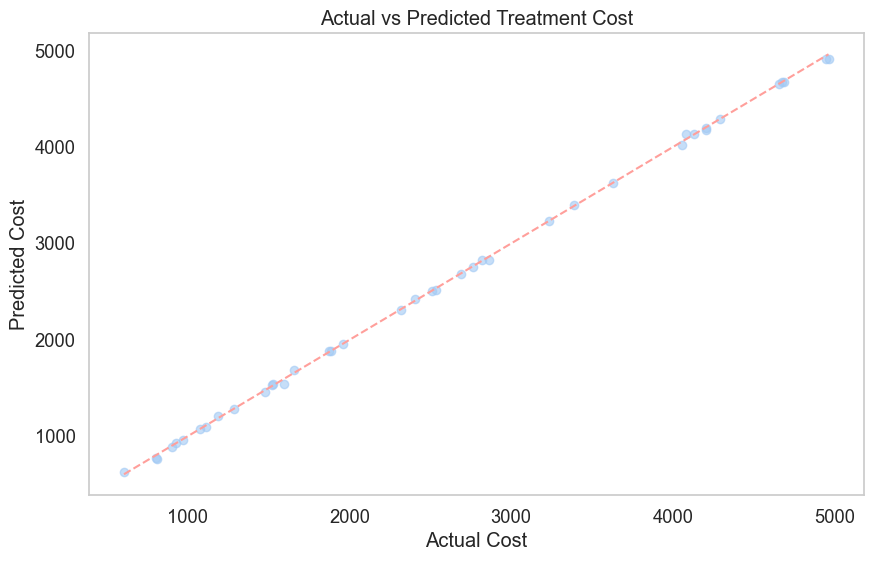

In [37]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.title('Actual vs Predicted Treatment Cost')
plt.xlabel('Actual Cost')
plt.ylabel('Predicted Cost')
plt.grid()
plt.show()